In [1]:
%matplotlib inline
import relplot as rp
import numpy as np
import matplotlib.pyplot as plt
rp.config.use_tex_fonts = False # can change this to True if you have LaTeX installed.

## sample data (miscalibrated)
N = 10000
f = np.random.rand(N)
y = (np.random.rand(N) > 1-(f + 0.2*np.sin(2*np.pi*f)))*1

## compute and plot
print('calibration error:', rp.smECE(f, y))
rp.rel_diagram(f, y);
rp.rel_diagram_binned(f, y); 

calibration error: 0.11173470283088668


In [2]:
path = '/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/my_outputs_vqa_random_march28/merged_scaled.csv'
import pandas as pd
df = pd.read_csv(path)

In [3]:
df.head()

,question_id,predictive_entropy,lexical_similarity,semantic_entropy,num_clusters,responses,resp_log_probs,question,accuracy,grounding_grounding_sam,...,grounding_clip_processed,grounding_clip_mean,predictive_entropy_min_max_scaled,lexical_similarity_min_max_scaled,semantic_entropy_min_max_scaled,num_clusters_min_max_scaled,grounding_grounding_sam_mean_min_max_scaled,grounding_qwen_vl_mean_min_max_scaled,grounding_llama32_11b_mean_min_max_scaled,grounding_clip_mean_min_max_scaled
0,208001,2.945212,0.992308,0.014661,2,"['The countertop is made of marble.', 'The cou...","[-0.12326052784919739, -0.12326052784919739, -...",What material is the countertop made of?,0.00,"[0.6436653137207031, 0.6436653137207031, 0.643...",...,"[25.191986083984375, 25.191986083984375, 25.19...",25.178478,0.983136,0.992100,0.006471,0.052632,0.625513,0.00,0.2,0.466730
1,589010,2.857616,1.000000,0.000000,1,"['The ground is green.', 'The ground is green....","[-0.18048983812332153, -0.18048983812332153, -...",What color is the ground?,1.00,"[0.590011715888977, 0.590011715888977, 0.59001...",...,"[23.116544723510742, 23.116544723510742, 23.11...",23.116545,0.953896,1.000000,0.000000,0.000000,0.550635,0.00,1.0,0.370034
2,675000,1.499087,0.467588,1.100244,15,"['The cat is drinking from a cup, likely a cof...","[-23.906789779663086, -12.206457138061523, -20...",What is the cat doing?,0.65,"[0.46566084027290344, 0.8307315111160278, 0.61...",...,"[31.17235565185547, 30.249950408935547, 28.849...",31.354617,0.500408,0.453199,0.485601,0.736842,0.733790,0.05,0.9,0.756366
3,1584014,2.172424,0.514038,1.231728,10,"['The picture is on the side of a red bus.', '...","[-6.3551530838012695, -6.5662126541137695, -5....",Where is the picture?,0.20,"[0.6190107464790344, 0.4913567900657654, 0.474...",...,"[28.174644470214844, 29.77653694152832, 28.234...",24.541725,0.725173,0.500904,0.543632,0.473684,0.402210,0.00,0.8,0.436869
4,1993002,2.731723,0.346083,0.817568,5,"['Yes', 'Yes', 'No', 'Yes, the window is open,...","[-1.1418246030807495, -1.1418246030807495, -2....",Is the window open?,0.65,"[0.5014057159423828, 0.5014057159423828, 0.318...",...,"[19.598718643188477, 19.598718643188477, 19.80...",20.703599,0.911872,0.328409,0.360839,0.210526,0.380986,0.40,0.4,0.256877


In [4]:
df.columns

Index(['question_id', 'predictive_entropy', 'lexical_similarity',
       'semantic_entropy', 'num_clusters', 'responses', 'resp_log_probs',
       'question', 'accuracy', 'grounding_grounding_sam',
       'grounding_grounding_sam_processed', 'grounding_grounding_sam_mean',
       'grounding_qwen_vl', 'grounding_qwen_vl_processed',
       'grounding_qwen_vl_mean', 'grounding_llama32_11b',
       'grounding_llama32_11b_processed', 'grounding_llama32_11b_mean',
       'grounding_clip', 'grounding_clip_processed', 'grounding_clip_mean',
       'predictive_entropy_min_max_scaled',
       'lexical_similarity_min_max_scaled', 'semantic_entropy_min_max_scaled',
       'num_clusters_min_max_scaled',
       'grounding_grounding_sam_mean_min_max_scaled',
       'grounding_qwen_vl_mean_min_max_scaled',
       'grounding_llama32_11b_mean_min_max_scaled',
       'grounding_clip_mean_min_max_scaled'],
      dtype='object')

--- Results for: lexical_similarity_min_max_scaled ---
Smoothed ECE (smECE): 0.24945040279067407


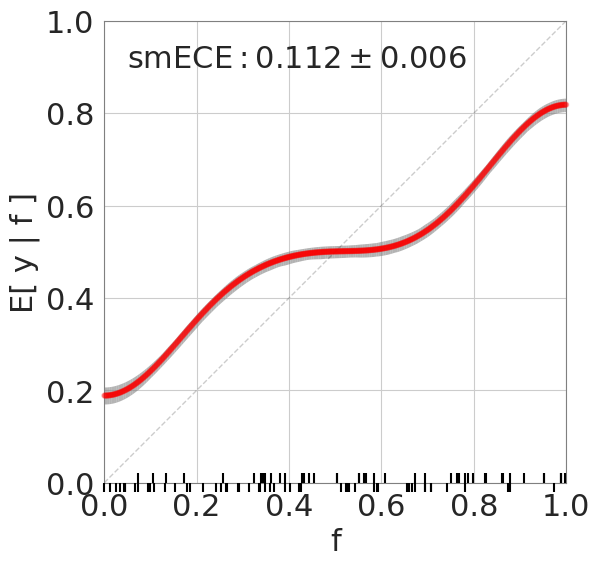

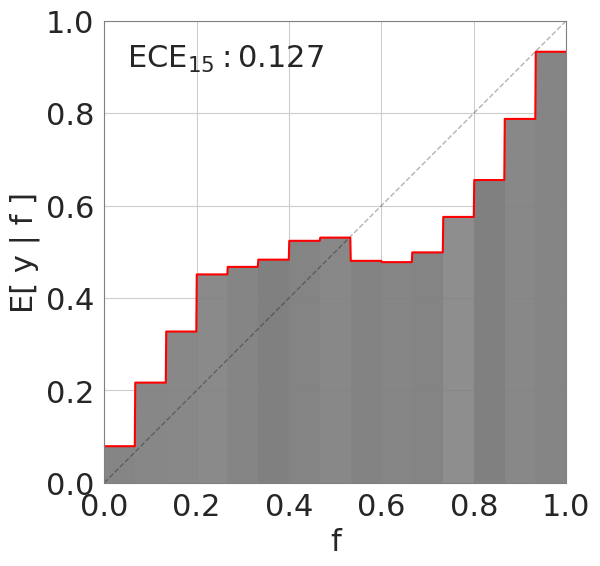

<Figure size 600x600 with 0 Axes>

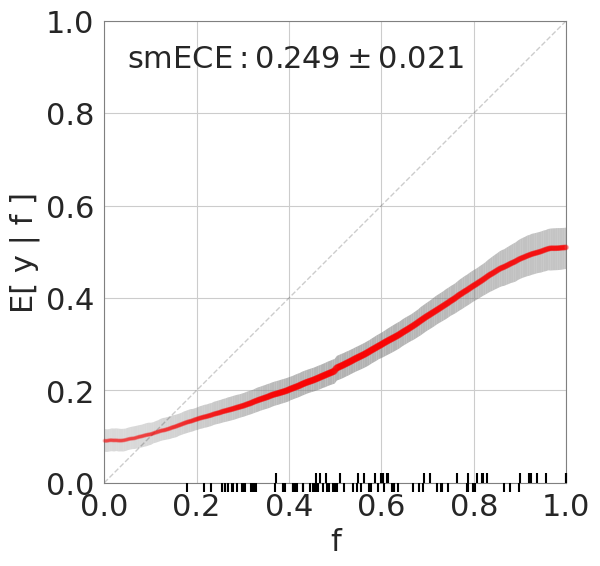

TypeError: rel_diagram_binned() got an unexpected keyword argument 'title'

In [5]:
# --- Using your dataset ---

# 1. Select your confidence score column for 'f'
# Example: using 'lexical_similarity_min_max_scaled'
confidence_column_name = 'lexical_similarity_min_max_scaled' 
# You can change this to other relevant columns like:
# 'num_clusters_min_max_scaled', 
# 'grounding_grounding_sam_mean_min_max_scaled', etc.
# or 1 - 'predictive_entropy_min_max_scaled' if you want to convert uncertainty to confidence

# 2. Select your accuracy column for 'y'
accuracy_column_name = 'accuracy'

# 3. Extract the data, ensuring no NaN values for these columns
# Create a temporary DataFrame to handle NaNs for the selected columns
temp_df = df[[confidence_column_name, accuracy_column_name]].copy()
temp_df.dropna(subset=[confidence_column_name, accuracy_column_name], inplace=True)

f_your_data = temp_df[confidence_column_name].values
y_your_data = temp_df[accuracy_column_name].values

# Ensure y_your_data is integer type (0 or 1)
y_your_data = y_your_data.astype(int)

# 4. Compute and plot using relplot
if len(f_your_data) > 0 and len(y_your_data) > 0:
    print(f"--- Results for: {confidence_column_name} ---")
    
    # Calculate smECE
    smece_score = rp.smECE(f_your_data, y_your_data)
    print(f'Smoothed ECE (smECE): {smece_score}')
    
    # Plot reliability diagram (smooth)
    plt.figure()
    rp.rel_diagram(f_your_data, y_your_data, title=f'Smooth Reliability Diagram - {confidence_column_name}')
    plt.show()
    
    # Plot binned reliability diagram
    plt.figure()
    rp.rel_diagram_binned(f_your_data, y_your_data, title=f'Binned Reliability Diagram - {confidence_column_name}')
    plt.show()
else:
    print(f"Not enough data for {confidence_column_name} after dropping NaNs, or columns not found.")

In [15]:
# path = '/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/SLAKE_GEMINI_FILTERED_JUNE1_eval_dfs/eval_df_fold_1.csv'
path = '/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/SLAKE_RANDOM_eval_dfs/eval_df_fold_1.csv'
df = pd.read_csv(path)

In [16]:
df.columns

Index(['grounding_biomedclip_mean_min_max_scaled',
       'grounding_llama32_11b_mean_min_max_scaled',
       'grounding_qwen_vl_mean_min_max_scaled',
       'lexical_similarity_min_max_scaled', 'num_clusters_min_max_scaled',
       'confidence_from_semantic_entropy_min_max_scaled',
       'confidence_from_predictive_entropy_min_max_scaled', 'accuracy',
       'temperature_scaled_lexical_similarity_min_max_scaled',
       'exponent_calibrated_grounding_biomedclip_mean_min_max_scaled_lexical_similarity_min_max_scaled',
       'temperature_scaled_gr_only_grounding_biomedclip_mean_min_max_scaled',
       'exponent_calibrated_grounding_llama32_11b_mean_min_max_scaled_lexical_similarity_min_max_scaled',
       'temperature_scaled_gr_only_grounding_llama32_11b_mean_min_max_scaled',
       'exponent_calibrated_grounding_qwen_vl_mean_min_max_scaled_lexical_similarity_min_max_scaled',
       'temperature_scaled_gr_only_grounding_qwen_vl_mean_min_max_scaled',
       'temperature_scaled_num_clust

--- Results for: exponent_calibrated_grounding_biomedclip_mean_min_max_scaled_lexical_similarity_min_max_scaled ---
Smoothed ECE (smECE): 0.18925743282798976


<Figure size 600x600 with 0 Axes>

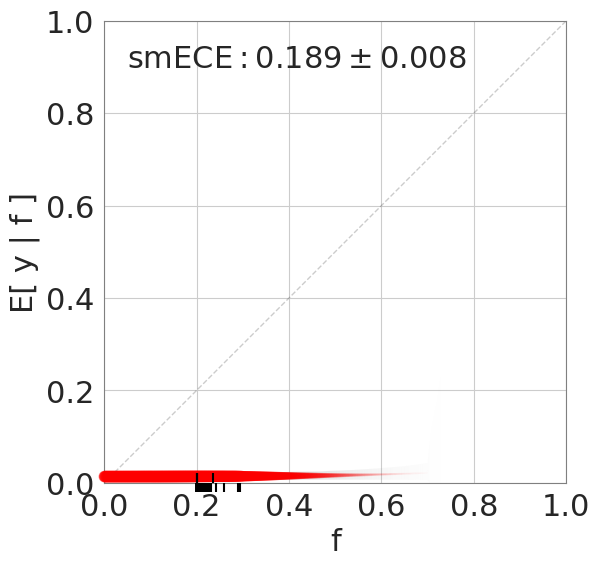

In [17]:
# exponent_calibrated_grounding_biomedclip_mean_min_max_scaled_lexical_similarity_min_max_scaled
confidence_column_name = 'exponent_calibrated_grounding_biomedclip_mean_min_max_scaled_lexical_similarity_min_max_scaled'
accuracy_column_name = 'accuracy'
# Create a temporary DataFrame to handle NaNs for the selected columns
temp_df = df[[confidence_column_name, accuracy_column_name]].copy()
temp_df.dropna(subset=[confidence_column_name, accuracy_column_name], inplace=True)
f_your_data = temp_df[confidence_column_name].values
y_your_data = temp_df[accuracy_column_name].values
# Ensure y_your_data is integer type (0 or 1)
y_your_data = y_your_data.astype(int)
# Compute and plot using relplot
if len(f_your_data) > 0 and len(y_your_data) > 0:
    print(f"--- Results for: {confidence_column_name} ---")
    
    # Calculate smECE
    smece_score = rp.smECE(f_your_data, y_your_data)
    print(f'Smoothed ECE (smECE): {smece_score}')
    
    # Plot reliability diagram (smooth)
    plt.figure()
    rp.rel_diagram(f_your_data, y_your_data, title=f'Smooth Reliability Diagram - {confidence_column_name}')
    plt.show()
    
    # # Plot binned reliability diagram
    # plt.figure()
    # rp.rel_diagram_binned(f_your_data, y_your_data, title=f'Binned Reliability Diagram - {confidence_column_name}')
    # plt.show()
    

In [18]:
accuracy_column_name = 'accuracy'

for i in df.columns:
    if 'exponent_calibrated' in i:  # Check in the current column name
        confidence_column_name = i 
        
        temp_df = df[[confidence_column_name, accuracy_column_name]].copy()
        temp_df.dropna(subset=[confidence_column_name, accuracy_column_name], inplace=True)
        f_your_data = temp_df[confidence_column_name].values
        y_your_data = temp_df[accuracy_column_name].values
        # Ensure y_your_data is integer type (0 or 1)
        y_your_data = y_your_data.astype(int)
        # Compute and plot using relplot
        if len(f_your_data) > 0 and len(y_your_data) > 0:
            print(f"--- Results for: {confidence_column_name} ---")
            
            # Calculate smECE
            smece_score = rp.smECE(f_your_data, y_your_data)
            print(f'Smoothed ECE (smECE): {smece_score}')
            
            # Plot reliability diagram (smooth)
            # plt.figure()
            # rp.rel_diagram(f_your_data, y_your_data, title=f'Smooth Reliability Diagram - {confidence_column_name}')
            # plt.show()
            
            # Plot binned reliability diagram
            # plt.figure()
            # rp.rel_diagram_binned(f_your_data, y_your_data, title=f'Binned Reliability Diagram - {confidence_column_name}')
            # plt.show()
        else:    
            print(f"Not enough data for {confidence_column_name} after dropping NaNs, or columns not found.")


--- Results for: exponent_calibrated_grounding_biomedclip_mean_min_max_scaled_lexical_similarity_min_max_scaled ---
Smoothed ECE (smECE): 0.18925743282798976
--- Results for: exponent_calibrated_grounding_llama32_11b_mean_min_max_scaled_lexical_similarity_min_max_scaled ---
Smoothed ECE (smECE): 0.16662222376509692
--- Results for: exponent_calibrated_grounding_qwen_vl_mean_min_max_scaled_lexical_similarity_min_max_scaled ---
Smoothed ECE (smECE): 0.21326200477343757
--- Results for: exponent_calibrated_grounding_biomedclip_mean_min_max_scaled_num_clusters_min_max_scaled ---
Smoothed ECE (smECE): 0.1892484173887855
--- Results for: exponent_calibrated_grounding_llama32_11b_mean_min_max_scaled_num_clusters_min_max_scaled ---
Smoothed ECE (smECE): 0.1948949401247452
--- Results for: exponent_calibrated_grounding_qwen_vl_mean_min_max_scaled_num_clusters_min_max_scaled ---
Smoothed ECE (smECE): 0.4251667903833089
--- Results for: exponent_calibrated_grounding_biomedclip_mean_min_max_scaled

In [20]:
baselines = ['lexical_similarity_min_max_scaled', 
            'num_clusters_min_max_scaled', 
            'confidence_from_semantic_entropy_min_max_scaled', 
            'confidence_from_predictive_entropy_min_max_scaled']

for baseline in baselines:
    confidence_column_name = baseline
    temp_df = df[[confidence_column_name, accuracy_column_name]].copy()
    temp_df.dropna(subset=[confidence_column_name, accuracy_column_name], inplace=True)
    f_your_data = temp_df[confidence_column_name].values
    y_your_data = temp_df[accuracy_column_name].values
    # Ensure y_your_data is integer type (0 or 1)
    y_your_data = y_your_data.astype(int)
    # Compute and plot using relplot
    if len(f_your_data) > 0 and len(y_your_data) > 0:
        print(f"--- Results for: {confidence_column_name} ---")
        
        # Calculate smECE
        smece_score = rp.smECE(f_your_data, y_your_data)
        print(f'Smoothed ECE (smECE): {smece_score}')
        
        # Plot reliability diagram (smooth)
        # plt.figure()
        # rp.rel_diagram(f_your_data, y_your_data, title=f'Smooth Reliability Diagram - {confidence_column_name}')
        # plt.show()
        
        # # Plot binned reliability diagram
        # plt.figure()
        # rp.rel_diagram_binned(f_your_data, y_your_data, title=f'Binned Reliability Diagram - {confidence_column_name}')
        # plt.show()
    else:    
        print(f"Not enough data for {confidence_column_name} after dropping NaNs, or columns not found.")

--- Results for: lexical_similarity_min_max_scaled ---
Smoothed ECE (smECE): 0.21326200477343757
--- Results for: num_clusters_min_max_scaled ---
Smoothed ECE (smECE): 0.45274114627498846
--- Results for: confidence_from_semantic_entropy_min_max_scaled ---
Smoothed ECE (smECE): 0.4297483627186112
--- Results for: confidence_from_predictive_entropy_min_max_scaled ---
Smoothed ECE (smECE): 0.4186705048841341


In [21]:
path = '/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/VQA_RANDOM_MARCH28_eval_dfs/eval_df_fold_1.csv'

df = pd.read_csv(path)

accuracy_column_name = 'accuracy'

for i in df.columns:
    if 'exponent_calibrated' in i:  # Check in the current column name
        confidence_column_name = i 
        
        temp_df = df[[confidence_column_name, accuracy_column_name]].copy()
        temp_df.dropna(subset=[confidence_column_name, accuracy_column_name], inplace=True)
        f_your_data = temp_df[confidence_column_name].values
        y_your_data = temp_df[accuracy_column_name].values
        # Ensure y_your_data is integer type (0 or 1)
        y_your_data = y_your_data.astype(int)
        # Compute and plot using relplot
        if len(f_your_data) > 0 and len(y_your_data) > 0:
            print(f"--- Results for: {confidence_column_name} ---")
            
            # Calculate smECE
            smece_score = rp.smECE(f_your_data, y_your_data)
            print(f'Smoothed ECE (smECE): {smece_score}')
            
            # Plot reliability diagram (smooth)
            # plt.figure()
            # rp.rel_diagram(f_your_data, y_your_data, title=f'Smooth Reliability Diagram - {confidence_column_name}')
            # plt.show()
            
            # Plot binned reliability diagram
            # plt.figure()
            # rp.rel_diagram_binned(f_your_data, y_your_data, title=f'Binned Reliability Diagram - {confidence_column_name}')
            # plt.show()
        else:    
            print(f"Not enough data for {confidence_column_name} after dropping NaNs, or columns not found.")



--- Results for: exponent_calibrated_grounding_grounding_sam_mean_min_max_scaled_lexical_similarity_min_max_scaled ---
Smoothed ECE (smECE): 0.3187228557953818
--- Results for: exponent_calibrated_grounding_qwen_vl_mean_min_max_scaled_lexical_similarity_min_max_scaled ---
Smoothed ECE (smECE): 0.3010553194808877
--- Results for: exponent_calibrated_grounding_llama32_11b_mean_min_max_scaled_lexical_similarity_min_max_scaled ---
Smoothed ECE (smECE): 0.33285517432061407
--- Results for: exponent_calibrated_grounding_clip_mean_min_max_scaled_lexical_similarity_min_max_scaled ---
Smoothed ECE (smECE): 0.3397614958731954
--- Results for: exponent_calibrated_grounding_grounding_sam_mean_min_max_scaled_num_clusters_min_max_scaled ---
Smoothed ECE (smECE): 0.24013854757475714
--- Results for: exponent_calibrated_grounding_qwen_vl_mean_min_max_scaled_num_clusters_min_max_scaled ---
Smoothed ECE (smECE): 0.25493710058549107
--- Results for: exponent_calibrated_grounding_llama32_11b_mean_min_max_

In [22]:
baselines = ['lexical_similarity_min_max_scaled', 
            'num_clusters_min_max_scaled', 
            'confidence_from_semantic_entropy_min_max_scaled', 
            'confidence_from_predictive_entropy_min_max_scaled']

for baseline in baselines:
    confidence_column_name = baseline
    temp_df = df[[confidence_column_name, accuracy_column_name]].copy()
    temp_df.dropna(subset=[confidence_column_name, accuracy_column_name], inplace=True)
    f_your_data = temp_df[confidence_column_name].values
    y_your_data = temp_df[accuracy_column_name].values
    # Ensure y_your_data is integer type (0 or 1)
    y_your_data = y_your_data.astype(int)
    # Compute and plot using relplot
    if len(f_your_data) > 0 and len(y_your_data) > 0:
        print(f"--- Results for: {confidence_column_name} ---")
        
        # Calculate smECE
        smece_score = rp.smECE(f_your_data, y_your_data)
        print(f'Smoothed ECE (smECE): {smece_score}')
        
        # Plot reliability diagram (smooth)
        # plt.figure()
        # rp.rel_diagram(f_your_data, y_your_data, title=f'Smooth Reliability Diagram - {confidence_column_name}')
        # plt.show()
        
        # # Plot binned reliability diagram
        # plt.figure()
        # rp.rel_diagram_binned(f_your_data, y_your_data, title=f'Binned Reliability Diagram - {confidence_column_name}')
        # plt.show()
    else:    
        print(f"Not enough data for {confidence_column_name} after dropping NaNs, or columns not found.")

--- Results for: lexical_similarity_min_max_scaled ---
Smoothed ECE (smECE): 0.2487716624448492
--- Results for: num_clusters_min_max_scaled ---
Smoothed ECE (smECE): 0.21797713811155403
--- Results for: confidence_from_semantic_entropy_min_max_scaled ---
Smoothed ECE (smECE): 0.35300483485932027
--- Results for: confidence_from_predictive_entropy_min_max_scaled ---
Smoothed ECE (smECE): 0.23653867296021716
